In [ ]:
full_name = "Fereshteh Zahra Hossain"

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

# Configure visualizations
sns.set(style="whitegrid")

## Overview

We will explore a dataset containing information about employees and use that data to train models capable of predicting whether those employees have left the company (attrited) or not. You will start by exploring the dataset, analyzing its features, and performing necessary preprocessing steps (such as label encoding and scaling). Then, you will build and evaluate implementations of K-Nearest Neighbors (KNN) as well as Random Forest, Bagging, and AdaBoost classifiers. After training and tuning each model, you’ll compare their performance using metrics like accuracy and feature importance to identify the best approach for accurate attrition prediction.

# Load and Explore Dataset 

In [6]:
import pandas as pd

# Load the dataset
# "Attrition" is our target columm

df = pd.read_csv('dataset.csv')
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,29,No,Travel_Rarely,592,Research & Development,7,3,Life Sciences,1,1883,...,2,80,0,11,2,3,3,2,1,2
1,34,No,Travel_Rarely,1326,Sales,3,3,Other,1,1478,...,4,80,0,15,2,3,13,9,3,12
2,27,No,Travel_Rarely,954,Sales,9,3,Marketing,1,1965,...,1,80,0,7,5,3,7,7,0,7
3,32,No,Travel_Rarely,929,Sales,10,3,Marketing,1,722,...,4,80,0,10,2,2,10,7,0,8
4,50,No,Travel_Frequently,1234,Research & Development,20,5,Medical,1,1606,...,3,80,1,32,3,3,30,8,12,13


Explore the dataset and get familiar with its features and statistics. (don't worry about the 'masked values' in our target column. They are simply used to automatically test your model later on.)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       902 non-null    int64 
 1   Attrition                 902 non-null    object
 2   BusinessTravel            902 non-null    object
 3   DailyRate                 902 non-null    int64 
 4   Department                902 non-null    object
 5   DistanceFromHome          902 non-null    int64 
 6   Education                 902 non-null    int64 
 7   EducationField            902 non-null    object
 8   EmployeeCount             902 non-null    int64 
 9   EmployeeNumber            902 non-null    int64 
 10  EnvironmentSatisfaction   902 non-null    int64 
 11  Gender                    902 non-null    object
 12  HourlyRate                902 non-null    int64 
 13  JobInvolvement            902 non-null    int64 
 14  JobLevel    

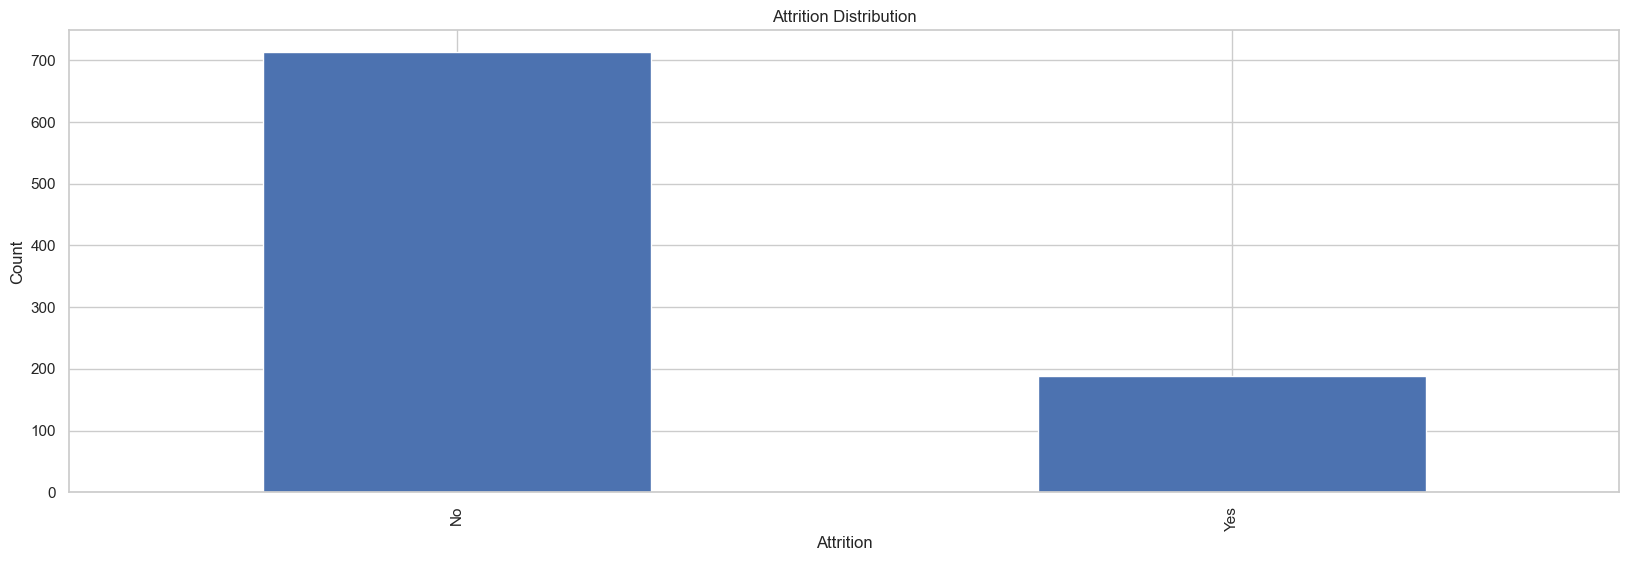

In [7]:
# TODO: Check the basic structure of the dataset using .info() and .describe()
# Use: df.info() to check data types and missing values
# Use: df.describe() to get summary statistics of numeric features

print("Dataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe())

# TODO: Check for any missing values in the dataset
# Use: df.isnull().sum() to find if any column has missing values

print("\nMissing values per column:")
print(df.isnull().sum())

# TODO: Explore the target variable (binary classification)
# Use value_counts() to see the distribution of our target (Attrition) column and then visualize it (bar plot).

print("\nAttrition distribution:")
print(df['Attrition'].value_counts())
plt.figure(figsize=(20,6))
df['Attrition'].value_counts().plot(kind='bar')
plt.title('Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

# df.head()

It is generally better to remove columns with only one unique value from a DataFrame when preparing data for a decision tree. <br>
Such columns do not provide any useful information for splitting the data and can lead to unnecessary complexity in the model. Remove the said columns from the DataFrame.

In [8]:
# TODO Measure and print the number of unique values for each column. 
# Check if there are any columns with less than 2 unique values. If so, remove them. 

unique_values = {}
for col in df.columns:
    unique_values[col] = df[col].nunique()
    print(f"{col}: {unique_values[col]} unique values")

# Find columns with less than 2 unique values
cols_to_drop = [col for col in df.columns if df[col].nunique() < 2]
print("\nColumns to drop (less than 2 unique values):", cols_to_drop)

# Drop them
df.drop(columns=cols_to_drop, inplace=True)
print("DataFrame shape after dropping:", df.shape)

Age: 42 unique values
Attrition: 2 unique values
BusinessTravel: 3 unique values
DailyRate: 653 unique values
Department: 3 unique values
DistanceFromHome: 29 unique values
Education: 5 unique values
EducationField: 6 unique values
EmployeeCount: 1 unique values
EmployeeNumber: 902 unique values
EnvironmentSatisfaction: 4 unique values
Gender: 2 unique values
HourlyRate: 71 unique values
JobInvolvement: 4 unique values
JobLevel: 5 unique values
JobRole: 9 unique values
JobSatisfaction: 4 unique values
MaritalStatus: 3 unique values
MonthlyIncome: 853 unique values
MonthlyRate: 888 unique values
NumCompaniesWorked: 10 unique values
Over18: 1 unique values
OverTime: 2 unique values
PercentSalaryHike: 15 unique values
PerformanceRating: 2 unique values
RelationshipSatisfaction: 4 unique values
StandardHours: 1 unique values
StockOptionLevel: 4 unique values
TotalWorkingYears: 40 unique values
TrainingTimesLastYear: 7 unique values
WorkLifeBalance: 4 unique values
YearsAtCompany: 34 unique

Look at the DataFrame and try to gather insight into people's monthly income and things that generally affect this number.

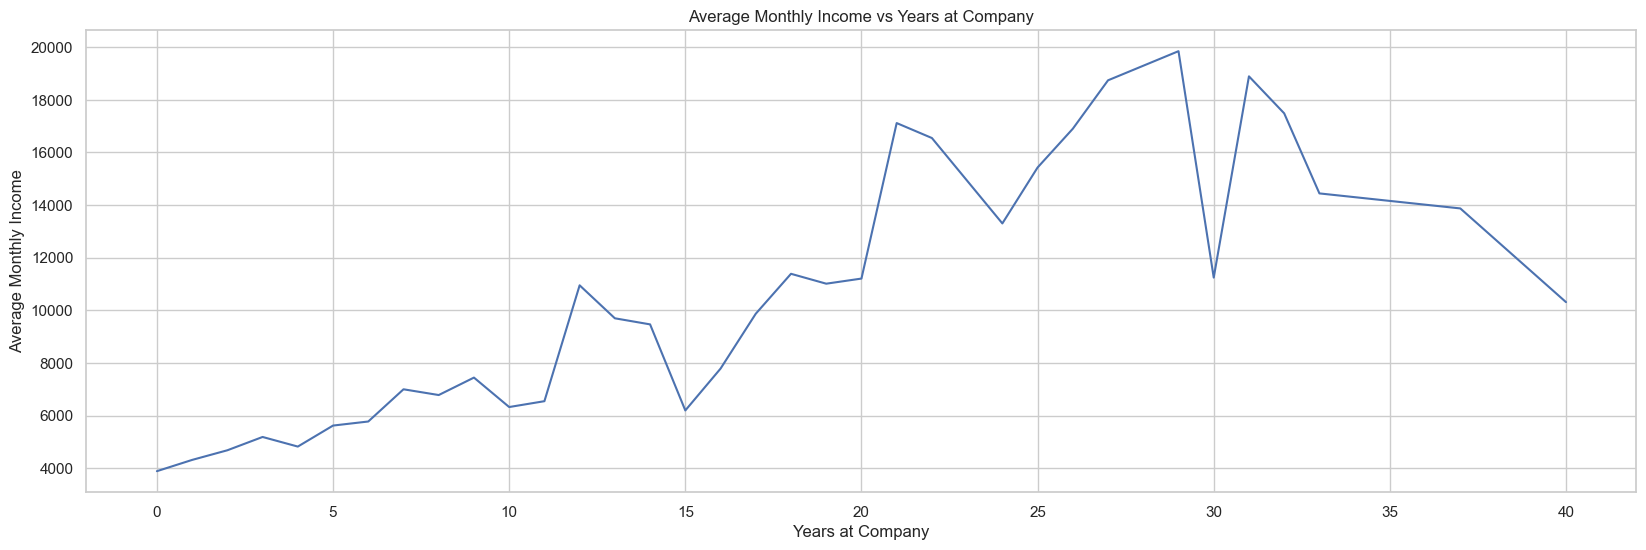

Average Monthly Income by Department:
Department
Research & Development    6073.644444
Human Resources           6564.333333
Sales                     6817.394366
Name: MonthlyIncome, dtype: float64
Highest: Sales with 6817.39
Lowest: Research & Development with 6073.64


In [9]:
# TODO: Plot (lineplot) the average MonthlyIncome against the YearsAtCompany. 
# TODO: Then find which departments have the highest and lowest incomes on average.

# Group by YearsAtCompany and compute mean MonthlyIncome
income_by_years = df.groupby('YearsAtCompany')['MonthlyIncome'].mean().reset_index()
plt.figure(figsize=(20,6))
sns.lineplot(data=income_by_years, x='YearsAtCompany', y='MonthlyIncome')
plt.title('Average Monthly Income vs Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Average Monthly Income')
plt.show()

# Department average income
dept_income = df.groupby('Department')['MonthlyIncome'].mean().sort_values()
print("Average Monthly Income by Department:")
print(dept_income)
print(f"Highest: {dept_income.index[-1]} with {dept_income.iloc[-1]:.2f}")
print(f"Lowest: {dept_income.index[0]} with {dept_income.iloc[0]:.2f}")

Correlation of MonthlyIncome with other numeric features:
JobLevel                    0.950988
TotalWorkingYears           0.763157
YearsAtCompany              0.506674
Age                         0.498928
YearsInCurrentRole          0.389586
YearsSinceLastPromotion     0.352082
YearsWithCurrManager        0.334057
NumCompaniesWorked          0.153377
Education                   0.080265
DailyRate                   0.040657
WorkLifeBalance             0.030909
MonthlyRate                 0.018498
RelationshipSatisfaction    0.016633
StockOptionLevel            0.008475
EnvironmentSatisfaction    -0.012792
PerformanceRating          -0.012799
EmployeeNumber             -0.013206
JobInvolvement             -0.013366
JobSatisfaction            -0.017637
PercentSalaryHike          -0.026735
TrainingTimesLastYear      -0.027861
DistanceFromHome           -0.031452
HourlyRate                 -0.046481
Name: MonthlyIncome, dtype: float64


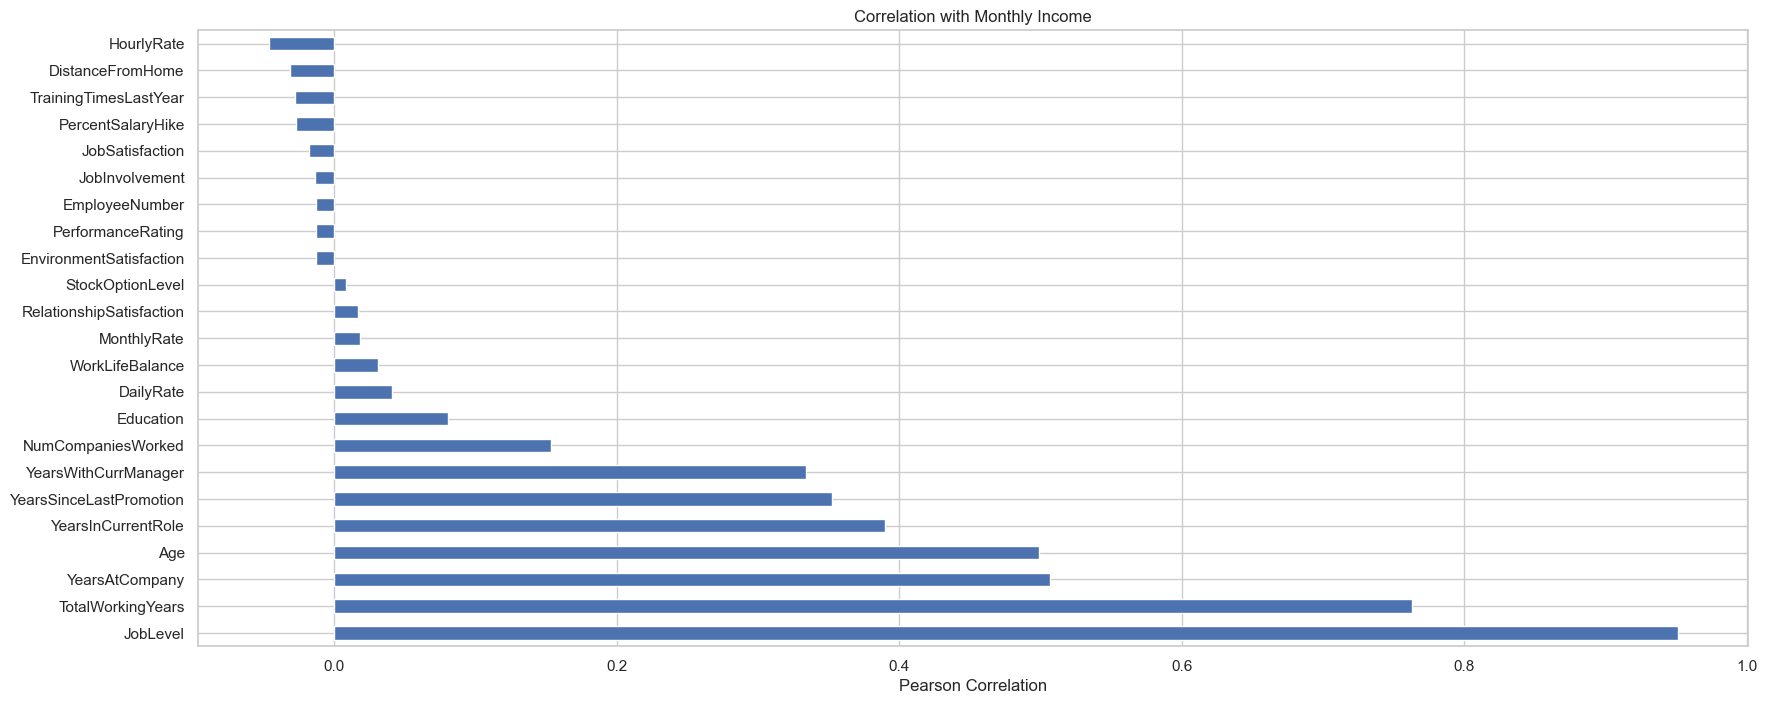

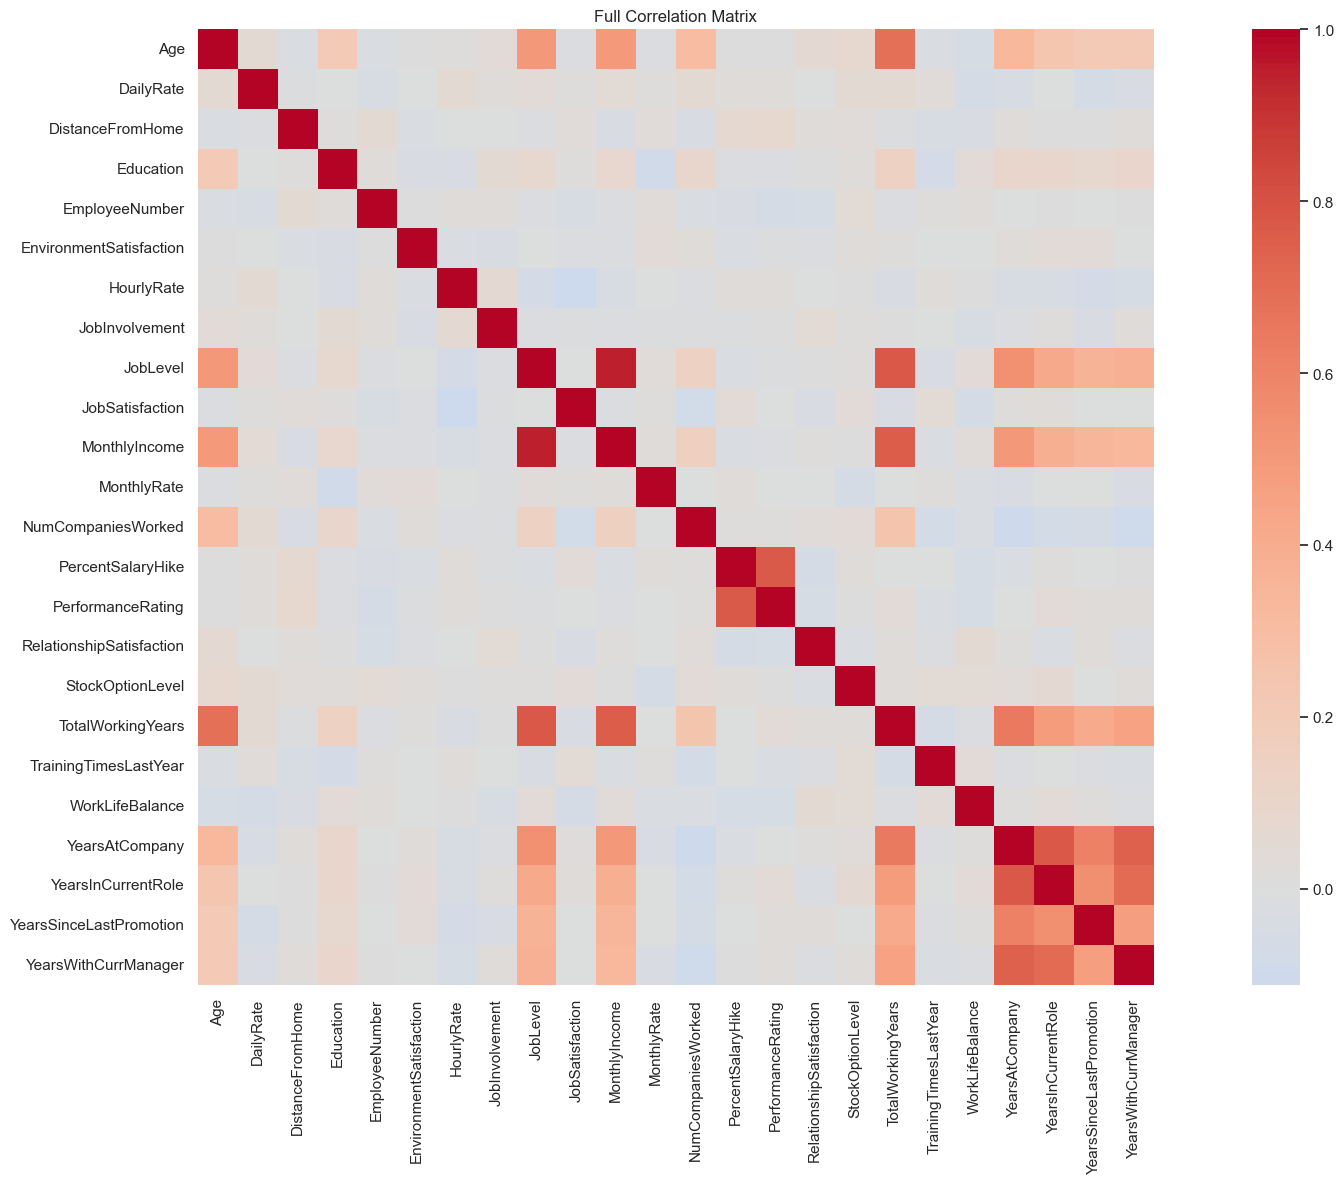

In [10]:
# Insight into people's monthly income and things that generally affect this number.
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
income_corr = corr_matrix['MonthlyIncome'].drop('MonthlyIncome').sort_values(ascending=False)

print("Correlation of MonthlyIncome with other numeric features:")
print(income_corr)

plt.figure(figsize=(20, 8))
income_corr.plot(kind='barh')
plt.title('Correlation with Monthly Income')
plt.xlabel('Pearson Correlation')

# Full heatmap of all correlations
plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Full Correlation Matrix')
plt.tight_layout()
plt.show()

# Data Preprocessing

Label Encode categorical columns and create a new DataFrame. Then split this data into train and test.

In [11]:
# TODO: Label encode all categorical columns
encoded_df = df.copy()
label_encoders = {}
categorical_cols = encoded_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(encoded_df[col])
    label_encoders[col] = le

encoded_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,29,0,2,592,1,7,3,1,1883,4,...,3,2,0,11,2,3,3,2,1,2
1,34,0,2,1326,2,3,3,4,1478,4,...,3,4,0,15,2,3,13,9,3,12
2,27,0,2,954,2,9,3,2,1965,4,...,3,1,0,7,5,3,7,7,0,7
3,32,0,2,929,2,10,3,2,722,4,...,3,4,0,10,2,2,10,7,0,8
4,50,0,1,1234,1,20,5,3,1606,2,...,3,3,1,32,3,3,30,8,12,13


In [12]:
# Split into features and target variable
X = encoded_df.drop(columns=['Attrition'])
y = encoded_df['Attrition']

# TODO: Perform a train-test split using train_test_split() from sklearn
# Split the dataset into training and test sets with a test size of 30%

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# TODO: Scale the features using StandardScaler
# Fit the scaler on the training data and transform both the training and test sets

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train_scaled)} samples")
print(pd.Series(y_train).value_counts())
print(f"Test set size: {len(X_test_scaled)} samples")
print(pd.Series(y_test).value_counts())

Training set size: 631 samples
Attrition
0    499
1    132
Name: count, dtype: int64
Test set size: 271 samples
Attrition
0    214
1     57
Name: count, dtype: int64


# K-Nearest Neighbors (KNN) Model 

Implement KNN model from scratch.

In [13]:
import numpy as np
from collections import Counter

class CustomKNN:
    def __init__(self, k):
        """
        Initialize the KNN classifier.

        Parameters:
        - k (int): Number of neighbors to consider.
        """
        # Store the number of neighbors (k)
        self.k = k

    def fit(self, X_train, y_train):
        """
        Fit the KNN classifier to the training data.

        Parameters:
        - X_train (numpy array): Training feature vectors.
        - y_train (numpy array): Training labels.
        """
        # Store training data
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)

    def euclidean_distance(self, x1, x2):
        """
        Calculate the Euclidean distance between two data points.

        Parameters:
        - x1 (numpy array): First data point.
        - x2 (numpy array): Second data point.

        Returns:
        - float: Euclidean distance between x1 and x2.
        """
        # TODO: Calculate and return the Euclidean distance

        return np.sqrt(np.sum((x1 - x2)**2))

    def predict(self, X_test):
        """
        Predict labels for test data.

        Parameters:
        - X_test (numpy array): Test feature vectors.

        Returns:
        - numpy array: Predicted labels.
        """
        # TODO: Predict label for each test instance and return the array of predictions
        
        X_test = np.array(X_test)
        predictions = [self._predict(x) for x in X_test]
        return np.array(predictions)

    def _predict(self, x):
        """
        Predict label for a single data point.

        Parameters:
        - x (numpy array): Test data point.

        Returns:
        - int: Predicted label.
        """
        # TODO: Compute distances from x to all training points.
        
        distances = [self.euclidean_distance(x, x_train) for x_train in self.X_train]
        
        # Find the indices and labels of k nearest neighbors.
        
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # Perform majority vote and return the most common label among them.
        
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

Fit and test your model using different k values and then choose the best one.

In [14]:
# The yes and no class are imbalanced in the training data (1:3.78)
smote_tomek = SMOTETomek(sampling_strategy=0.8, random_state=42)          # minority becomes 0.8 * majority after oversampling
under = RandomUnderSampler(sampling_strategy=0.8, random_state=42)        # then majority reduced to almost match minority

X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train_scaled, y_train)
X_train_resampled, y_train_resampled = under.fit_resample(X_train_resampled, y_train_resampled)

# Checking new class distribution
print("After resampling training data:")
print(pd.Series(y_train_resampled).value_counts())


# Optional. You can choose any range of k values that you want.
k_values = range(1,26)
accuracies = []

best_accuracy = 0
best_k = None

for k in k_values:
    y_pred_custom= []
    
    # TODO: Fit the model using the scaled training data

    model = CustomKNN(k=k)
    model.fit(X_train_resampled, y_train_resampled)  # y_train is pandas Series, convert to numpy
    
    # TODO: Make predictions on the scaled test data

    y_pred_custom = model.predict(X_test_scaled)
    
    # TODO: Evaluate the model's accuracy for each value of k and choose the best one
    
    acc = accuracy_score(y_test, y_pred_custom)
    accuracies.append(acc)
    print(f'k: {k} - Accuracy: {acc:.16f}')
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_k = k
        
Best_custom_model= CustomKNN(k=best_k)  #considering accuracy
Best_custom_model.fit(X_train_resampled, y_train_resampled)


# Keep the best k value (needed later on with bagging)
bestk= best_k
print(f"\nBest k: {bestk} with accuracy: {best_accuracy}")

After resampling training data:
Attrition
0    498
1    399
Name: count, dtype: int64
k: 1 - Accuracy: 0.6715867158671587
k: 2 - Accuracy: 0.6715867158671587
k: 3 - Accuracy: 0.6605166051660517
k: 4 - Accuracy: 0.6715867158671587
k: 5 - Accuracy: 0.6605166051660517
k: 6 - Accuracy: 0.6826568265682657
k: 7 - Accuracy: 0.6346863468634686
k: 8 - Accuracy: 0.6383763837638377
k: 9 - Accuracy: 0.6457564575645757
k: 10 - Accuracy: 0.6494464944649446
k: 11 - Accuracy: 0.6346863468634686
k: 12 - Accuracy: 0.6531365313653137
k: 13 - Accuracy: 0.6309963099630996
k: 14 - Accuracy: 0.6531365313653137
k: 15 - Accuracy: 0.6457564575645757
k: 16 - Accuracy: 0.6420664206642066
k: 17 - Accuracy: 0.6383763837638377
k: 18 - Accuracy: 0.6420664206642066
k: 19 - Accuracy: 0.6346863468634686
k: 20 - Accuracy: 0.6383763837638377
k: 21 - Accuracy: 0.6199261992619927
k: 22 - Accuracy: 0.6420664206642066
k: 23 - Accuracy: 0.6199261992619927
k: 24 - Accuracy: 0.6383763837638377
k: 25 - Accuracy: 0.616236162361623

In [15]:
# Checking recall for the postive class
k_values = range(1,26)
recalls = []

best_recall= 0

best_k_for_recall= None 

for k in k_values:
    y_pred_custom= []
    
    model = CustomKNN(k=k)
    model.fit(X_train_resampled, y_train_resampled) 
    
    y_pred_custom = model.predict(X_test_scaled)
        
    # Evaluating the model's recall for the minority class ('yes/1')
    rec=recall_score(y_test, y_pred_custom, pos_label=1)
    recalls.append(rec)
    print(f'k: {k} - Recall: {rec:.16f}')

    if rec > best_recall:
        best_recall = rec
        best_k_for_recall = k

Best_recall_model= CustomKNN(k=best_k_for_recall)  #considering recall
Best_recall_model.fit(X_train_resampled, y_train_resampled)
print(f"\nBest k: {best_k_for_recall} with recall for 'yes' : {best_recall}")

k: 1 - Recall: 0.4736842105263158
k: 2 - Recall: 0.4736842105263158
k: 3 - Recall: 0.6315789473684210
k: 4 - Recall: 0.6315789473684210
k: 5 - Recall: 0.6491228070175439
k: 6 - Recall: 0.6491228070175439
k: 7 - Recall: 0.7017543859649122
k: 8 - Recall: 0.6842105263157895
k: 9 - Recall: 0.7368421052631579
k: 10 - Recall: 0.7192982456140351
k: 11 - Recall: 0.7543859649122807
k: 12 - Recall: 0.7017543859649122
k: 13 - Recall: 0.7192982456140351
k: 14 - Recall: 0.7017543859649122
k: 15 - Recall: 0.7192982456140351
k: 16 - Recall: 0.6842105263157895
k: 17 - Recall: 0.7543859649122807
k: 18 - Recall: 0.7192982456140351
k: 19 - Recall: 0.7368421052631579
k: 20 - Recall: 0.7017543859649122
k: 21 - Recall: 0.7368421052631579
k: 22 - Recall: 0.7368421052631579
k: 23 - Recall: 0.7192982456140351
k: 24 - Recall: 0.7192982456140351
k: 25 - Recall: 0.7192982456140351

Best k: 11 with recall for 'yes' : 0.7543859649122807


In [16]:
# TODO: Print the accuracy and classification report using sklearn's metrics for your best model
y_pred_best = Best_custom_model.predict(X_test_scaled)
print("Best KNN Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Best KNN Model Accuracy: 0.6826568265682657

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.69      0.77       214
           1       0.36      0.65      0.46        57

    accuracy                           0.68       271
   macro avg       0.62      0.67      0.62       271
weighted avg       0.77      0.68      0.71       271



In [17]:
# Recall and classification report using sklearn's metrics for the best recall model
y_recall_pred_best = Best_recall_model.predict(X_test_scaled)
print("Best KNN Model Recall:", recall_score(y_test, y_recall_pred_best, pos_label=1))
print("\nClassification Report:\n", classification_report(y_test, y_recall_pred_best))

Best KNN Model Recall: 0.7543859649122807

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.60      0.72       214
           1       0.34      0.75      0.46        57

    accuracy                           0.63       271
   macro avg       0.62      0.68      0.59       271
weighted avg       0.78      0.63      0.67       271



Visualize the confusion matrix for KNN predictions

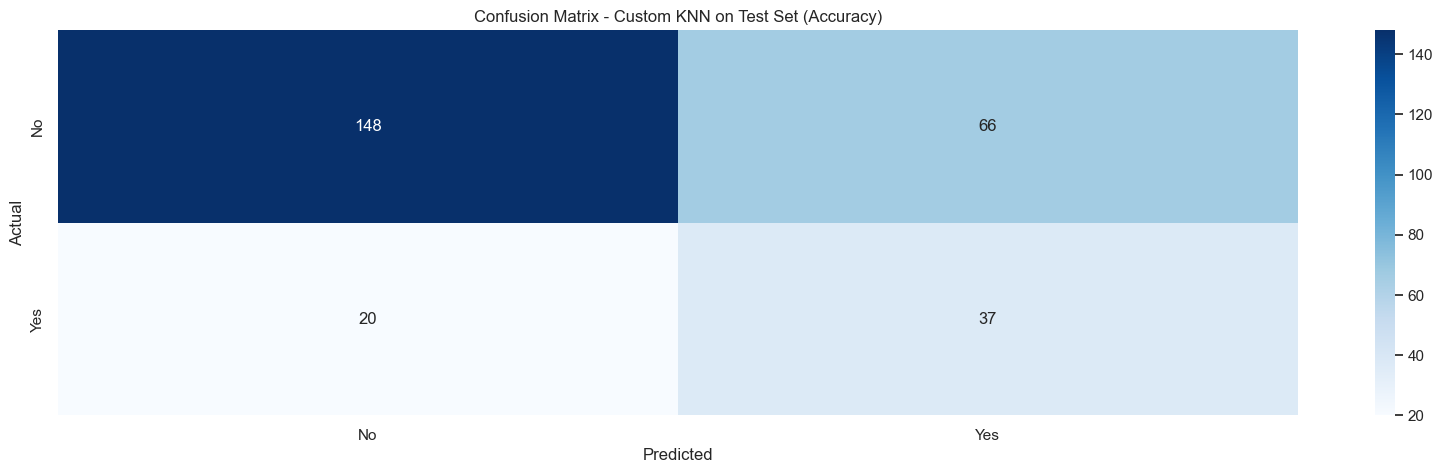

In [18]:
# TODO: Create a confusion matrix for KNN predictions
# Use confusion_matrix from sklearn.metrics

cm = confusion_matrix(y_test, y_pred_best)  #considering accuracy

# TODO: Visualize the confusion matrix using seaborn's heatmap
# Add annotations and a title for better readability

plt.figure(figsize=(20,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - Custom KNN on Test Set (Accuracy)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

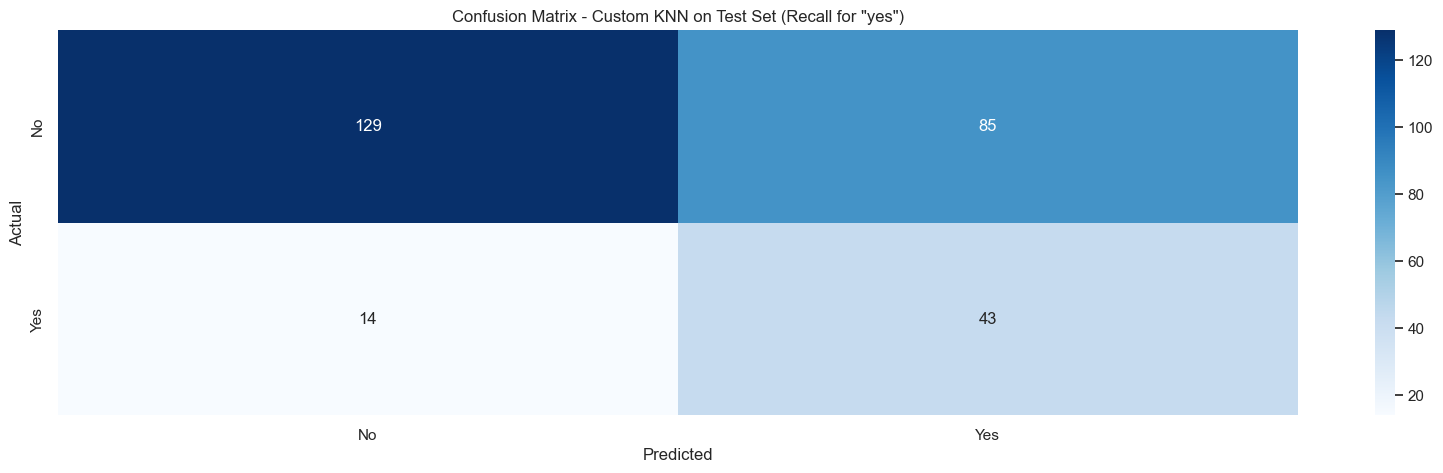

In [19]:
cm = confusion_matrix(y_test, y_recall_pred_best)  #considering recall

plt.figure(figsize=(20,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - Custom KNN on Test Set (Recall for "yes")')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Observation: In both best accuracy model and best recall model for KNN, we have considerable false positives in the test set due to the resampling (SMOTE and Undersampling) the imbalanced 'yes' and 'no' attrition classes 'only' in the training set, not in the test set. 

Recall was considered alongside accuracy because:

1) The goal is to predict employee attrition, so recall for the positive class (attrition = 'yes').The cost of missing an employee who is likely to leave (false negative) is high: unexpected turnover disrupts teams, hiring costs, and loss of company knowledge. We want to catch as many potential leavers as possible, even if it means occasionally flagging someone who wasn’t actually going to leave (false positives).

2) Accuracy can be misleading with imbalanced classes. However, we can’t ignore precision entirely. If we flag too many employees as potential leavers (low precision), we might waste resources. The F1‑score (harmonic mean of precision and recall) for the positive class is perhaps a good metric to balance both. 


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.82      0.89       499
           1       0.58      0.96      0.72       132

    accuracy                           0.85       631
   macro avg       0.78      0.89      0.81       631
weighted avg       0.90      0.85      0.86       631



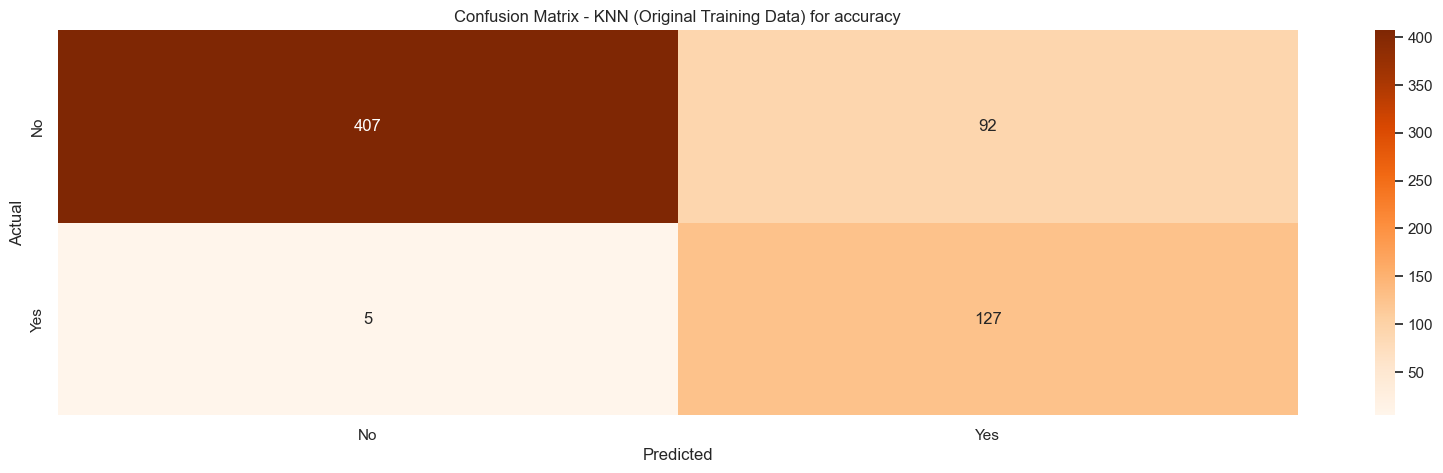


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.82      0.89       498
           1       0.81      0.98      0.89       399

    accuracy                           0.89       897
   macro avg       0.90      0.90      0.89       897
weighted avg       0.91      0.89      0.89       897



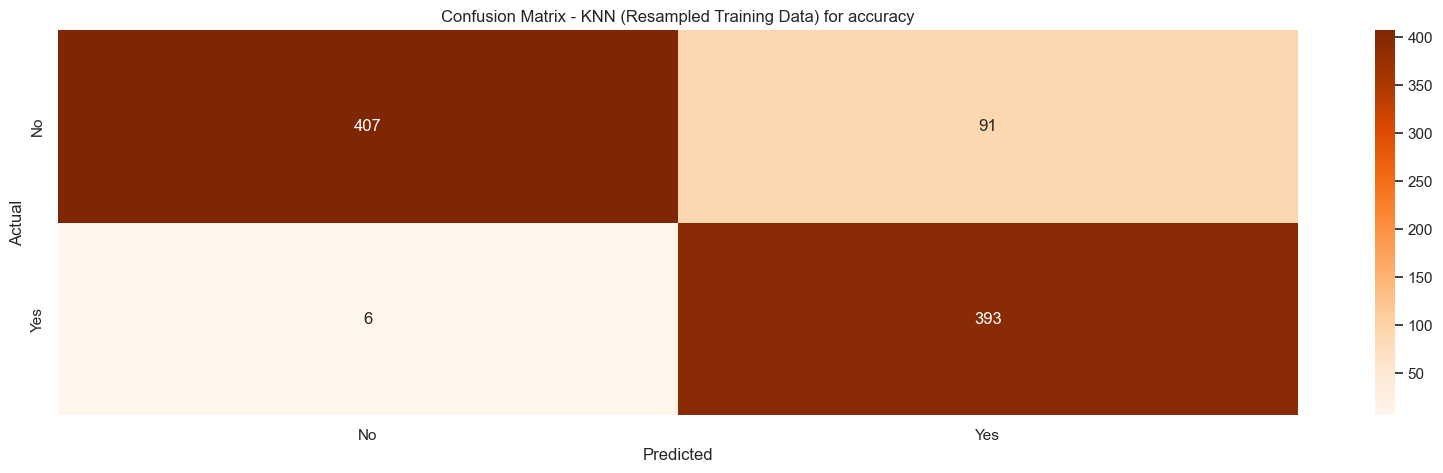

In [20]:
# Checking for overfit/underfit accuracy version

# Predicting on original training data
y_train_pred = Best_custom_model.predict(X_train_scaled)

# Creating confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)

print("\nClassification Report:\n", classification_report(y_train, y_train_pred))

# Visualizing
plt.figure(figsize=(20,5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Oranges', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - KNN (Original Training Data) for accuracy')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Predicting on resampled training data
y_train_pred = Best_custom_model.predict(X_train_resampled)

# Creating confusion matrix
cm_train = confusion_matrix(y_train_resampled, y_train_pred)

print("\nClassification Report:\n", classification_report(y_train_resampled, y_train_pred))

# Visualizing
plt.figure(figsize=(20,5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Oranges', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - KNN (Resampled Training Data) for accuracy')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.69      0.80       499
           1       0.42      0.86      0.56       132

    accuracy                           0.72       631
   macro avg       0.68      0.77      0.68       631
weighted avg       0.84      0.72      0.75       631



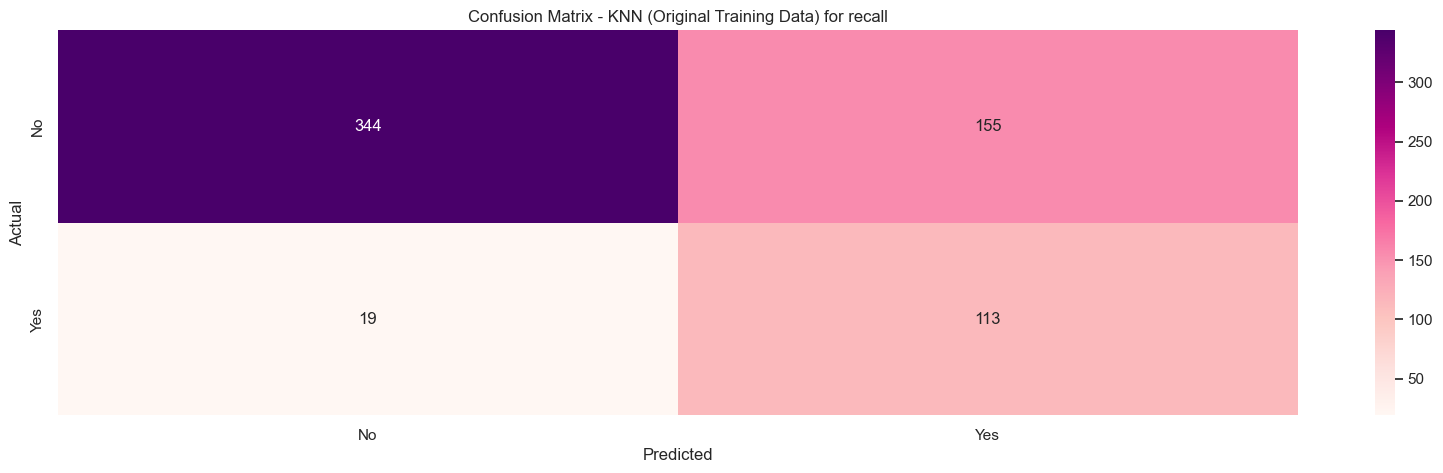


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.82      0.89       498
           1       0.81      0.98      0.89       399

    accuracy                           0.89       897
   macro avg       0.90      0.90      0.89       897
weighted avg       0.91      0.89      0.89       897



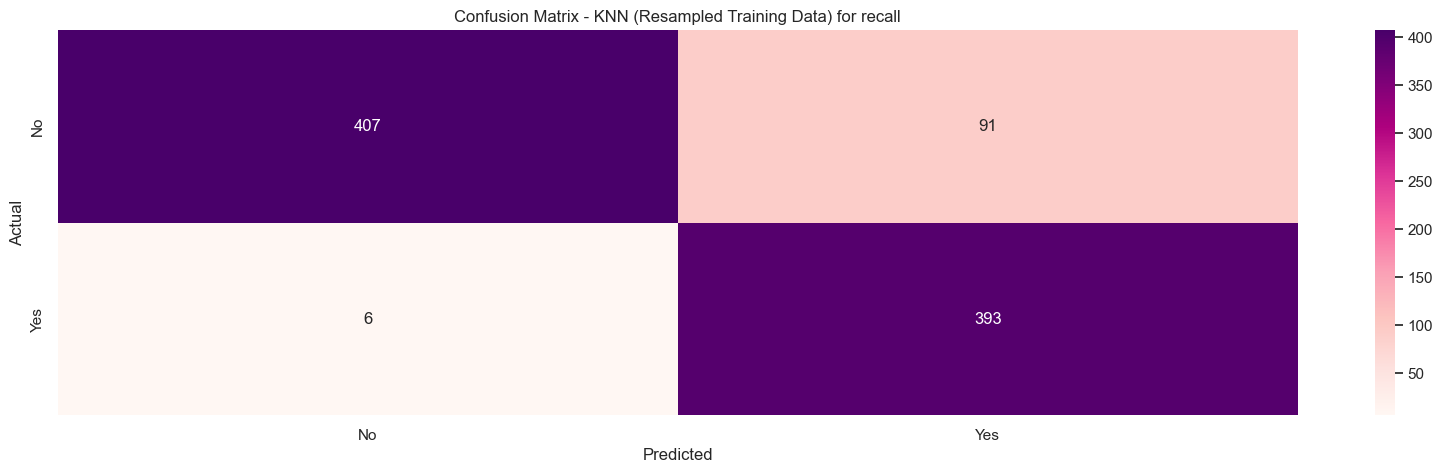

In [21]:
# Checking for overfit/underfit recall version

# Predicting on original training data
y_train_pred = Best_recall_model.predict(X_train_scaled)

# Creating confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)

print("\nClassification Report:\n", classification_report(y_train, y_train_pred))

# Visualizing
plt.figure(figsize=(20,5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='RdPu', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - KNN (Original Training Data) for recall')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Predicting on resampled training data
y_train_pred = Best_custom_model.predict(X_train_resampled)

# Creating confusion matrix
cm_train = confusion_matrix(y_train_resampled, y_train_pred)

print("\nClassification Report:\n", classification_report(y_train_resampled, y_train_pred))

# Visualizing
plt.figure(figsize=(20,5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='RdPu', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - KNN (Resampled Training Data) for recall')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Explained variance ratio: [0.16271507 0.07010876]
Total variance retained: 23.28%


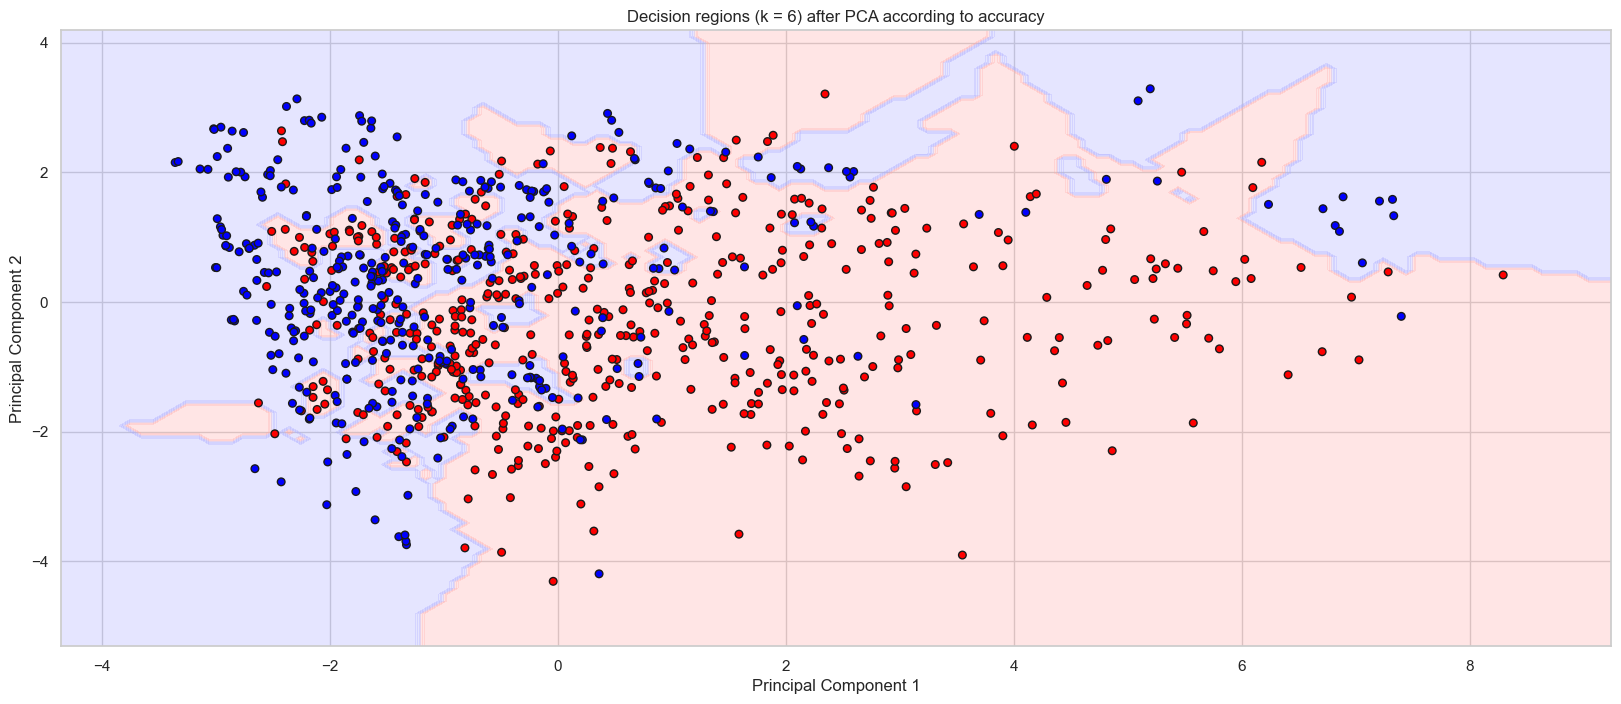

In [22]:
# Comparing Voronoi Diagrams

from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

# Reducing the resampled training data to 2 principal components
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_resampled)

# Checking how much variance is retained
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance retained: {sum(pca.explained_variance_ratio_):.2%}")

# Training a new KNN on the 2D data using the best k found earlier
vis_knn = CustomKNN(k=best_k)  #accuracy
vis_knn.fit(X_train_2d, y_train_resampled)

# Creating a mesh grid covering the 2D space
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predicting class for every point in the mesh
Z = vis_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting the decision regions and the training points
plt.figure(figsize=(20, 8))
# red=no, blue=yes
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])  # light red / light blue
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])    # bold red / bold blue

plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_resampled, cmap=cmap_bold, edgecolor='k', s=30)
plt.title(f'Decision regions (k = {best_k}) after PCA according to accuracy')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Explained variance ratio: [0.16271507 0.07010876]
Total variance retained: 23.28%


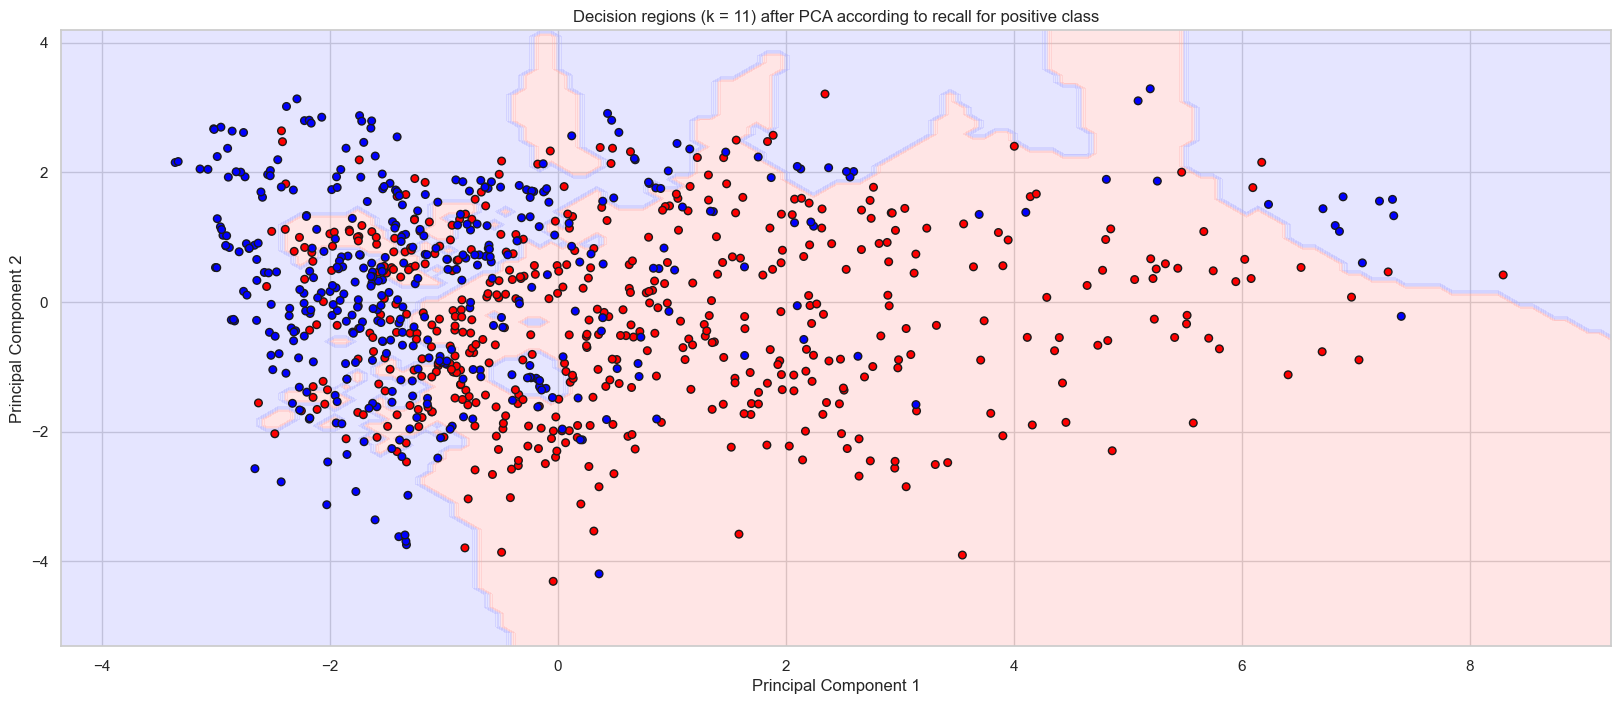

In [23]:
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_resampled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance retained: {sum(pca.explained_variance_ratio_):.2%}")

vis_knn = CustomKNN(k=best_k_for_recall) #recall
vis_knn.fit(X_train_2d, y_train_resampled)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))


Z = vis_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(20, 8))
# red=no, blue=yes
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])  # light red / light blue
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])    # bold red / bold blue

plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_resampled, cmap=cmap_bold, edgecolor='k', s=30)
plt.title(f'Decision regions (k = {best_k_for_recall}) after PCA according to recall for positive class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## Evaluation 
In this part, we are going to evaluate your model's performance on another set of unseen data. Load test.csv (this data is already encoded), use your best_custom_model to predict and save the results in a DataFrame called 'result.csv'. The DataFrame should contain one column called 'target' that contains your model's predictions.

In [24]:
# Load test.csv
eval_df= pd.read_csv('test.csv')

# TODO: Use your old scaler to scale the data
feature_columns = X.columns.tolist()
X_eval_scaled = scaler.transform(eval_df[feature_columns])

# TODO: Predict using your model
y_pred_eval = Best_custom_model.predict(X_eval_scaled) # cosidering accuracy

Save the results in a DataFrame

In [25]:
# Save the results as a csv file
result_df= pd.DataFrame()
result_df['target']=pd.Series(y_pred_eval)
result_df.to_csv('result.csv', index= False)

# Random Forest Model

Implement a random forest model using sklearn.

In [26]:
# TODO: Implement the Random Forest model

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# TODO: Set up a hyperparameter tuning process for Random Forest using GridSearchCV
# Suggested parameter grid: {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV with Random Forest

rf_cv = GridSearchCV(rf, param_grid_rf, cv=5, n_jobs=-1)

# TODO: Fit the GridSearchCV on the training data to find the best parameters
# Use rf_cv.fit() with the training data

rf_cv.fit(X_train_resampled, y_train_resampled) 

# TODO: Use the best Random Forest model for predictions on the test data
# Use rf_cv.best_estimator_ and predict()

best_rf = rf_cv.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

# TODO: Print the Random Forest model accuracy and classification report using sklearn's metrics
# Use accuracy_score and classification_report

print("Random Forest Best Parameters:", rf_cv.best_params_)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf, pos_label=1))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Accuracy: 0.8634686346863468
Random Forest Recall: 0.5087719298245614

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       214
           1       0.76      0.51      0.61        57

    accuracy                           0.86       271
   macro avg       0.82      0.73      0.76       271
weighted avg       0.86      0.86      0.85       271



Visualize the confusion matrix for Random Forest predictions

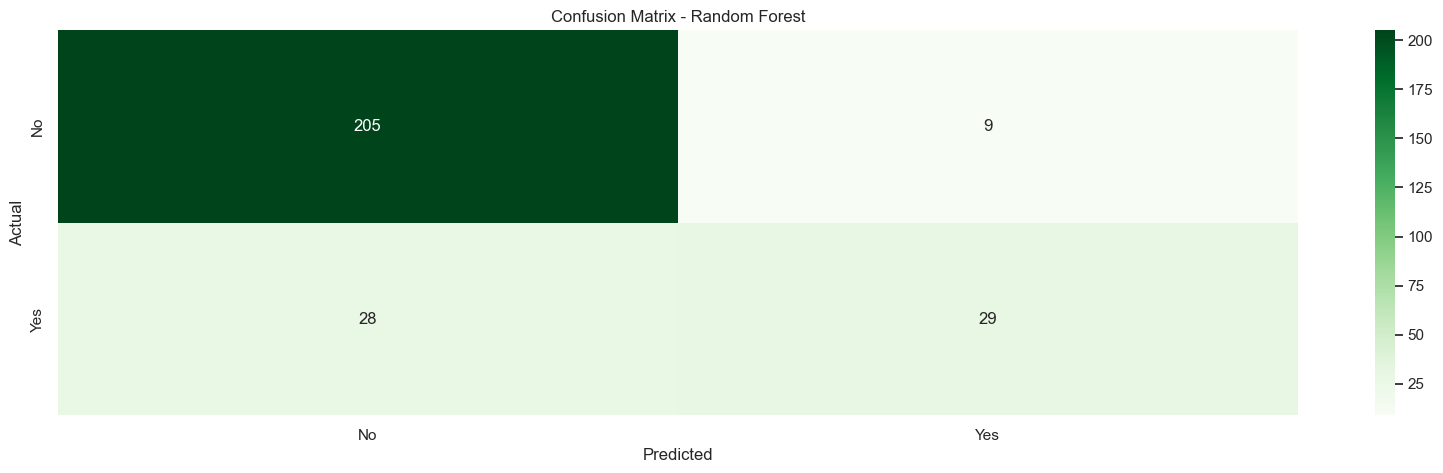

In [27]:
# TODO: Create a confusion matrix for Random Forest predictions
# Use confusion_matrix from sklearn.metrics

cm_rf = confusion_matrix(y_test, y_pred_rf)

# TODO: Visualize the confusion matrix using seaborn's heatmap
# Add annotations and a title for better readability

plt.figure(figsize=(20,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

A feature importance plot is a visual representation that illustrates the significance of each feature (or variable) in a machine learning model, particularly in the context of supervised learning tasks like classification and regression. Plot the feature importances using a bar plot.

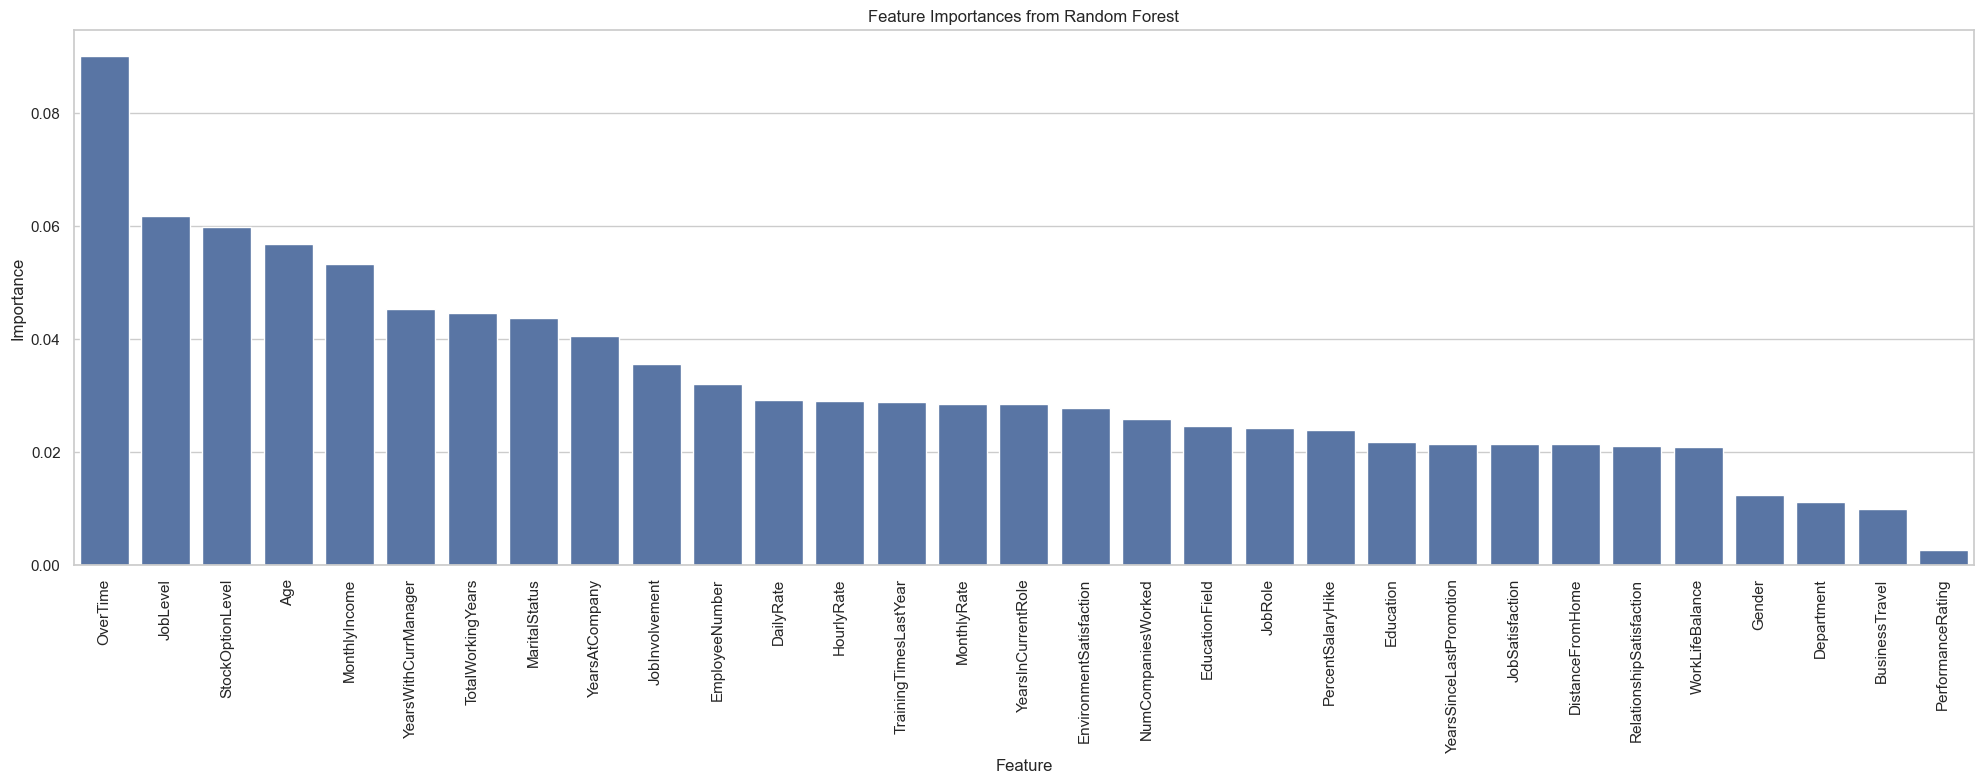

In [28]:
# Get the feature importances from the trained Random Forest model
importances= best_rf.feature_importances_

# TODO: Sort the indices of the importance values in descending order

indices = np.argsort(importances)[::-1]

# TODO: Create a DataFrame that contains the feature names and their corresponding importance scores

feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

# TODO: Create a bar plot to visualize feature importances using Seaborn

plt.figure(figsize=(20, 8))
sns.barplot(data=importance_df.head(32), x='Feature', y='Importance')
plt.title('Feature Importances from Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance')

# use tick_params and Rotate the x-axis labels for better readability

ax = plt.gca()
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

# Bagging with KNN 

In [29]:
# TODO: Implement Bagging with KNN
# Use BaggingClassifier with KNeighborsClassifier as the base estimator
# Here we use the bestk value we found before

bagging_knn = BaggingClassifier(KNeighborsClassifier(n_neighbors=bestk), n_estimators=50, random_state=42)

# TODO: Fit the BaggingClassifier on the scaled training data
# Use bagging_knn.fit() with the training data

bagging_knn.fit(X_train_resampled, y_train_resampled)

# TODO: Use the trained Bagging model for predictions on the test data
# Use bagging_knn.predict()

y_pred_bagging = bagging_knn.predict(X_test_scaled)

# TODO: Print the Bagging KNN model accuracy and classification report
# Use accuracy_score and classification_report
print("Bagging KNN Accuracy:", accuracy_score(y_test, y_pred_bagging))
print("Bagging KNN Recall:", recall_score(y_test, y_pred_bagging, pos_label=1))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bagging))

Bagging KNN Accuracy: 0.6494464944649446
Bagging KNN Recall: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.64      0.74       214
           1       0.33      0.67      0.44        57

    accuracy                           0.65       271
   macro avg       0.61      0.66      0.59       271
weighted avg       0.76      0.65      0.68       271



Visualize the confusion matrix for Baggin KNN predictions

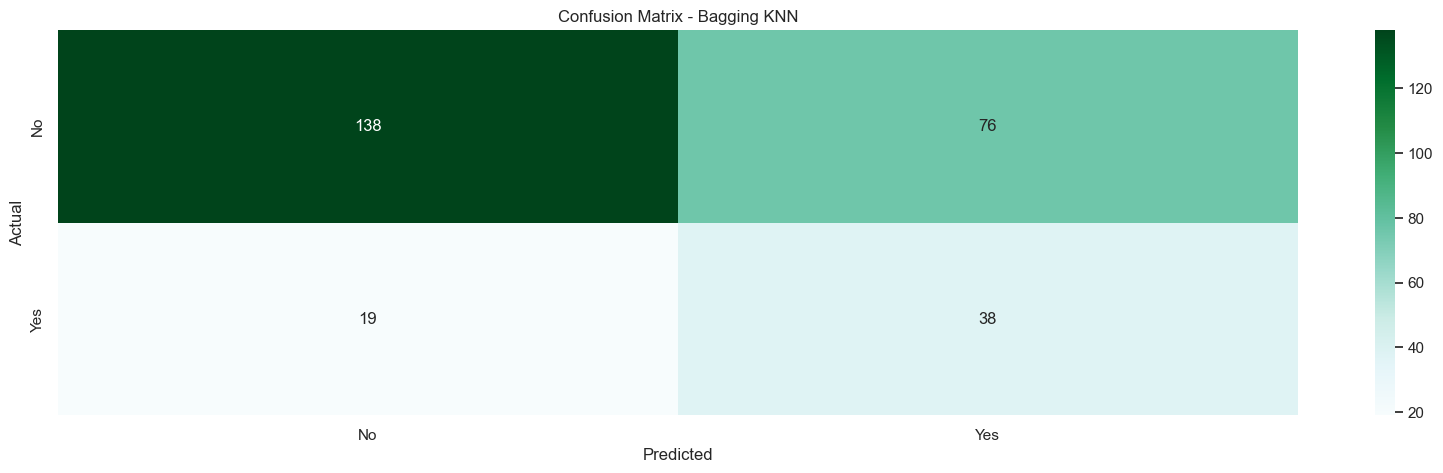

In [30]:
# TODO: Create a confusion matrix for Bagging KNN predictions
# Use confusion_matrix from sklearn.metrics

cm_bag = confusion_matrix(y_test, y_pred_bagging)

# TODO: Visualize the confusion matrix using seaborn's heatmap
# Add annotations and a title for better readability

plt.figure(figsize=(20,5))
sns.heatmap(cm_bag, annot=True, fmt='d', cmap='BuGn', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - Bagging KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# AdaBoost Model 

In [31]:
# TODO: Implement AdaBoost model

adaboost = AdaBoostClassifier(random_state=42)

# TODO: Set up a hyperparameter tuning process for AdaBoost using GridSearchCV
# Suggested parameter grid: {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 1.0]}

param_grid_ada = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0]
}

# GridSearchCV with AdaBoost

adaboost_cv = GridSearchCV(adaboost, param_grid_ada, cv=5, n_jobs=-1)

# TODO: Fit the GridSearchCV on the training data to find the best parameters
# Use adaboost_cv.fit() with the training data

# adaboost_cv.fit(X_train_scaled, y_train)
adaboost_cv.fit(X_train_resampled, y_train_resampled)

# TODO: Use the best AdaBoost model for predictions on the test data
# Use adaboost_cv.best_estimator_ and predict()

best_ada = adaboost_cv.best_estimator_
y_pred_ada = best_ada.predict(X_test_scaled)

# TODO: Print the AdaBoost model accuracy and classification report using sklearn's metrics
# Use accuracy_score and classification_report
print("AdaBoost Best Parameters:", adaboost_cv.best_params_)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("AdaBoost Recall:", recall_score(y_test, y_pred_ada, pos_label=1))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))

AdaBoost Best Parameters: {'learning_rate': 1.0, 'n_estimators': 150}
AdaBoost Accuracy: 0.8487084870848709
AdaBoost Recall: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.90       214
           1       0.63      0.67      0.65        57

    accuracy                           0.85       271
   macro avg       0.77      0.78      0.78       271
weighted avg       0.85      0.85      0.85       271



Visualize the confusion matrix for AdaBoost predictions

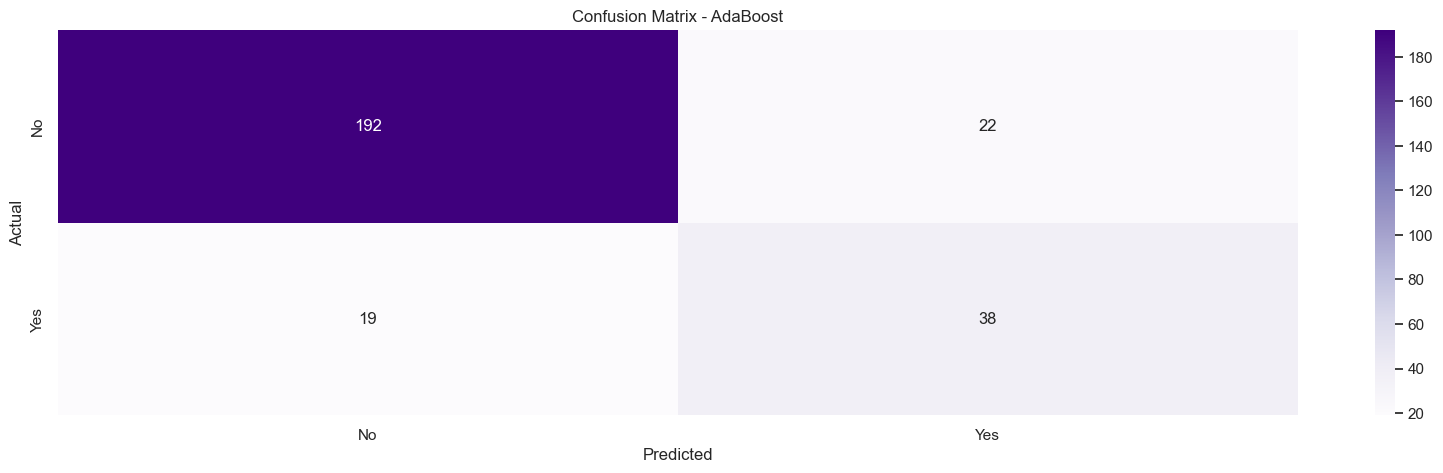

In [32]:
# TODO: Create a confusion matrix for AdaBoost predictions
# Use confusion_matrix from sklearn.metrics

cm_ada = confusion_matrix(y_test, y_pred_ada)

# TODO: Visualize the confusion matrix using seaborn's heatmap
# Add annotations and a title for better readability

plt.figure(figsize=(20,5))
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Purples', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - AdaBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Model Comparison 

           Model  Accuracy
0     Custom KNN  0.682657
1  Random Forest  0.863469
2    Bagging KNN  0.649446
3       AdaBoost  0.848708


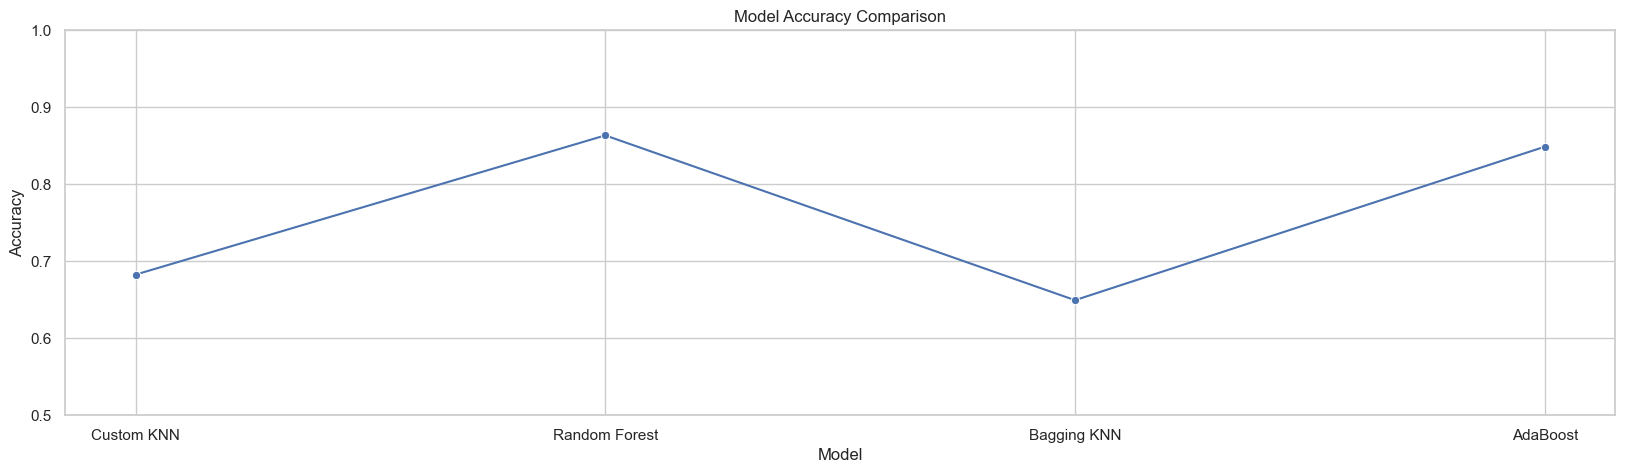

In [33]:
# TODO: Compare model accuracies for KNN, Random Forest, Bagging KNN, and AdaBoost
# Create a DataFrame with model names and their respective accuracies

accuracies_dict = {
    'Custom KNN': accuracy_score(y_test, y_pred_best),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'Bagging KNN': accuracy_score(y_test, y_pred_bagging),
    'AdaBoost': accuracy_score(y_test, y_pred_ada)
}

comparison_df = pd.DataFrame(list(accuracies_dict.items()), columns=['Model', 'Accuracy'])
print(comparison_df)

# TODO: Visualize the model comparison using a line plot
# Use seaborn's lineplot to plot model names vs. accuracies

plt.figure(figsize=(20,5))
sns.lineplot(data=comparison_df, x='Model', y='Accuracy', marker='o')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0) 
plt.grid(True)
plt.show()

           Model    Recall
0     Custom KNN  0.754386
1  Random Forest  0.508772
2    Bagging KNN  0.666667
3       AdaBoost  0.666667


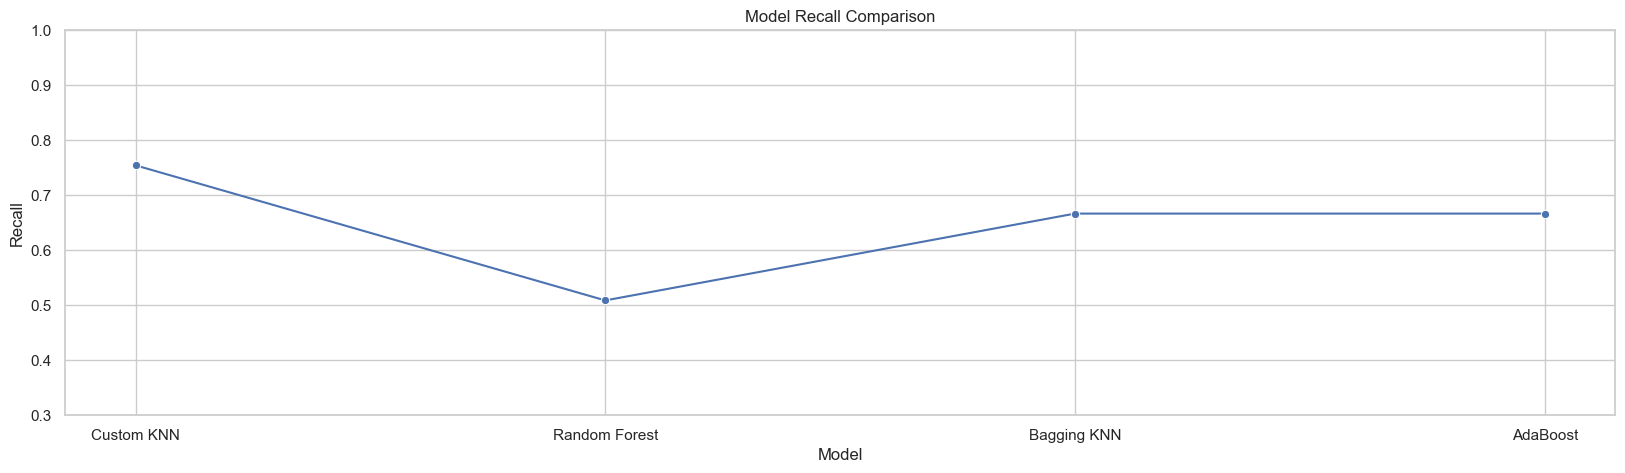

In [34]:
recalls_dict = {
    'Custom KNN': recall_score(y_test, y_recall_pred_best, pos_label=1),
    'Random Forest': recall_score(y_test, y_pred_rf, pos_label=1),
    'Bagging KNN': recall_score(y_test, y_pred_bagging, pos_label=1),
    'AdaBoost': recall_score(y_test, y_pred_ada, pos_label=1)
}

comparison_df = pd.DataFrame(list(recalls_dict.items()), columns=['Model', 'Recall'])
print(comparison_df)

plt.figure(figsize=(20,5))
sns.lineplot(data=comparison_df, x='Model', y='Recall', marker='o')
plt.title('Model Recall Comparison')
plt.xlabel('Model')
plt.ylabel('Recall')
plt.ylim(0.3, 1.0)
plt.grid(True)
plt.show()